In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#load dataset
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())
print(df.isnull().sum())

(200, 5)
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


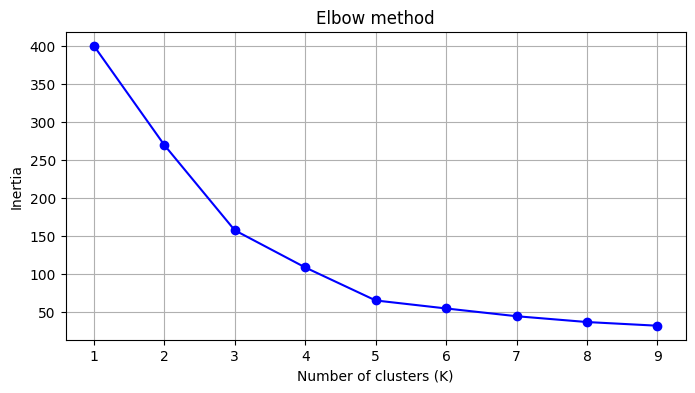

In [5]:
#Using only income and spending for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#try K from 1 to 10 and record inertia
inertias = []
K_range = range(1, 10)

for K in K_range:
    kmeans = KMeans(n_clusters = K, random_state = 42, n_init = 10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

#plot elbow curve
plt.figure(figsize = (8,4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.xticks(K_range)
plt.grid(True)
plt.show()
    

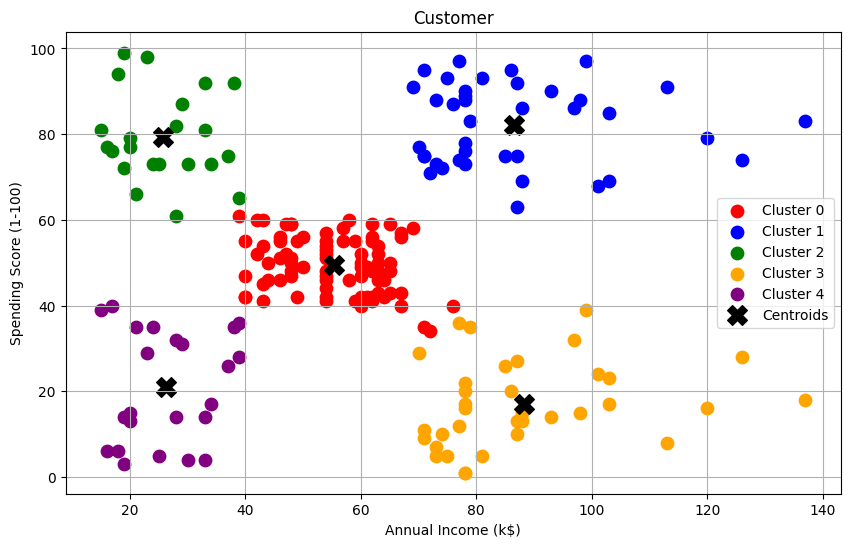

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [10]:
#training final model with k = 5
kmeans_final = KMeans(n_clusters = 5, random_state = 42, n_init = 10)
kmeans_final.fit(X_scaled)

#adding Cluster label to original df
df['Cluster'] = kmeans_final.labels_

#Visualize clusters
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for cluster in range(5):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        c = colors[cluster],
        label = f"Cluster {cluster}",
        s = 80
    )

#plot centroid
centroids =scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c = 'black', marker = 'X', s = 200, label = 'Centroids')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer")
plt.legend()
plt.grid(True)
plt.show()

#print  cluster summary
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())
    
    
                
